# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**The Question:** Which highly visible pages are significantly under-capturing clicks compared to their position tier peers?

**The Decision:** Deciding which pages a human SEO reviewer should spend their limited time investigating first.

**The Action:** Rewriting the title tag, meta description, or adjusting on-page snippets to better match search intent.

**Cost of a wrong call:** Wasting a human reviewer's time investigating a page that is actually performing fine, or chasing directional noise where a fix won't yield meaningful traffic.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data Source:** The 30,000-row anonymized starter dataset (`content_refresh_anonymized.csv`), built from real Google Search Console (GSC) and Google Analytics 4 (GA4) performance data over a 90-day trailing window.

**Filtering:** I restricted the analysis to pages with `impressions_90d >= 100` and `avg_position > 0` to filter out absolute noise and unranked pages, resulting in a core dataset of 22,006 highly visible pages across 30 clients.

**Exclusions (Leakage Prevention):**
* `trend_pct` and `is_declining_label` were strictly excluded because they contain the future outcome.
* FlyRank product flags like `priority_score` were excluded to prevent circular logic.
* `ctr` and `clicks_90d` were excluded from the feature set because they are used directly to calculate the target label.

*All data used is public-safe and contains no client names, URLs, or raw search queries.*

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Features:** 5 observable variables known at the time of decision: `impressions_90d`, `avg_position`, `content_age_days`, `word_count`, and `engagement_rate`.

**Label Definition:** Since true causal data (e.g., "did a rewrite fix it?") isn't available, I used an observed proxy label. A page is flagged as an anomaly (`is_ctr_anomaly = 1`) if its CTR is less than half (0.5x) the median CTR of its exact peer group (same `position_tier` and `content_type`).

**Validation Design:** A strict `GroupShuffleSplit` on `client_id` (75/25 split). This ensures no page from a test client is ever seen during training. As proven in my Week 6 audit, a naive random split inflated Precision@50 to 94% due to client-overlap leakage, whereas the grouped split yielded an honest 64%.

**Baseline:** A hand-written business rule scoring pages based on "wasted impressions" (high volume + Page 1 / Striking distance + low CTR).

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
file_path = "../../data/raw/content_refresh_anonymized.csv"
if not os.path.exists(file_path):
    file_path = "https://raw.githubusercontent.com/Bibek-Dhakal/applied-search-intelligence/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(file_path)
df = df[(df["impressions_90d"] >= 100) & (df["avg_position"] > 0)].copy().reset_index(drop=True)

# 2. Define Label & Features
peer_median = df.groupby(["position_tier", "content_type"])["ctr"].transform("median")
df["is_ctr_anomaly"] = (df["ctr"] < 0.5 * peer_median).astype(int)

FEATURES = ["impressions_90d", "avg_position", "content_age_days", "word_count", "engagement_rate"]
X = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_ctr_anomaly"].values

# 3. Client-Grouped Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
test_df = df.iloc[test_idx].copy()

# 4. Train Model
rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:, 1]

# 5. Compute Baseline Rule
def baseline_score(row):
    if row["avg_position"] <= 10 and row["impressions_90d"] >= 500 and row["ctr"] < 1.5:
        return row["impressions_90d"] * (1.5 - row["ctr"])
    elif 10 < row["avg_position"] <= 20 and row["impressions_90d"] >= 250 and row["ctr"] < 1.0:
        return (row["impressions_90d"] * 0.5) * (1.0 - row["ctr"])
    return 0.0

baseline_scores = test_df.apply(baseline_score, axis=1).values

# 6. Evaluate
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

random_chance = y_test.mean()

results = []
for k in (20, 50):
    results.append({"method": "Random chance", "k": k, "precision_at_k": round(random_chance, 3)})
    results.append({"method": "Week-4 Baseline Rule", "k": k, "precision_at_k": round(precision_at_k(baseline_scores, y_test, k), 3)})
    results.append({"method": "Random Forest (Grouped Split)", "k": k, "precision_at_k": round(precision_at_k(rf_scores, y_test, k), 3)})

results_df = pd.DataFrame(results).pivot(index="method", columns="k", values="precision_at_k")
results_df.columns = [f"Precision@{k}" for k in results_df.columns]

print(f"Test Set: {len(test_df)} rows | Base Positive Rate: {random_chance:.3f}\n")
display(results_df.sort_values(by="Precision@50", ascending=False))

Test Set: 4610 rows | Base Positive Rate: 0.286



,Precision@20,Precision@50
method,,
Random Forest (Grouped Split),0.850,0.640
Random chance,0.286,0.286
Week-4 Baseline Rule,0.350,0.260


## 5. Limitations

*What this work cannot claim.*

**What this work cannot claim:**
*   **Correlation vs. Causation:** This model identifies *observed* CTR gaps. It does not causally prove that updating a page's metadata will recover the clicks.
*   **Zero-Click SERPs & Brand Queries:** The data cannot distinguish between a page that has a bad title tag, versus a page that ranks for a "Zero-Click" AI Overview, or a query where the user specifically wanted a competitor's brand.
*   **Thin-Volume Noise:** At lower impression counts (e.g., exactly 100 impressions and 0 clicks), CTR estimates are mathematically noisy. Small-sample variance can trigger false positives.
*   **Generalizability:** The precision observed (0.640) applies to this specific 25-client holdout mix. It is intended as **decision-support** to order a queue, not as an automated publishing pipeline.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Based on the intersection of the Baseline Rule and the Model Probability Score, pages are assigned to an **Action Playbook Archetype**. Reviewers should work top-down:

1. **`confirmed_high_volume_miss` (High Priority):** Model confidence is high (>= 70%) AND the baseline rule agrees. Action: Priority rewrite of title/meta and search intent check.
2. **`striking_distance_push` (High Priority):** Model confidence is high, ranks 11-20, >= 250 impressions. Action: On-page optimization and internal linking to push to Page 1.
3. **`quiet_risk_flag` (Medium Priority):** Model flags it, but the rule missed it. Action: Human investigation required.
4. **`thin_volume_low_confidence` (Low Priority):** Model flagged it, but impressions are < 250. Action: Monitor only. Do not act on thin-volume noise.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

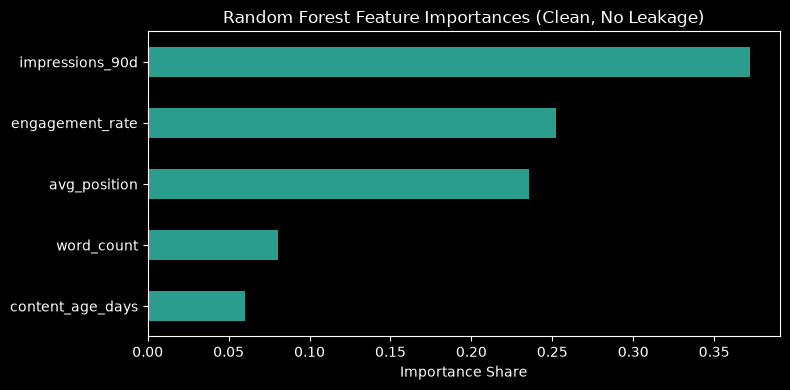

Artifacts generated successfully.


In [2]:
import matplotlib.pyplot as plt

# Generate a clean Feature Importance chart for the paper
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="#2a9d8f")
plt.title("Random Forest Feature Importances (Clean, No Leakage)")
plt.xlabel("Importance Share")
plt.tight_layout()

# Save the figure so it can be embedded in the HTML paper
os.makedirs("../../work/figures", exist_ok=True)
plt.savefig("../../work/figures/capstone_feature_importance.png", dpi=150)
plt.show()

print("Artifacts generated successfully.")

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.